# Allocentric vs Egocentric Quiz Generator

This notebook is structured for step-by-step execution:

1. Run **Cell 2** to load helper functions.
2. Run **Cell 3** to define a scenario and generate one quiz figure.
3. Tweak the scenario parameters (distance, relative angles, headings) to create new test/distractor sets.

In [32]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import transforms
from matplotlib.patches import Circle, FancyArrowPatch

ICON_A = plt.imread(Path('droso1_sm.jpg'))
ICON_B = plt.imread(Path('droso2_sm.jpg'))

def north_cw_to_math_rad(angle_deg):
    return np.deg2rad(90 - angle_deg)

def unit_from_north_cw(angle_deg):
    ang = np.deg2rad(angle_deg)
    return np.array([np.sin(ang), np.cos(ang)])

def vector_to_north_cw(vec):
    x, y = vec
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

def setup_panel(ax, title=None):
    ax.set_aspect('equal')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title:
        ax.set_title(title, fontsize=13, weight='bold')

def draw_icon(ax, icon_img, pos, heading_rad, size=0.16, alpha=1.0):
    x, y = pos
    h, w = icon_img.shape[:2]
    half_w = size
    half_h = size * (h / w)
    extent = [x - half_w, x + half_w, y - half_h, y + half_h]

    # Rotate around the geometric center of the rendered image extent.
    cx = 0.5 * (extent[0] + extent[1])
    cy = 0.5 * (extent[2] + extent[3])

    # Icon files are authored facing North (up).
    # Convert math heading (0=East, pi/2=North) into rotation relative to North-up baseline.
    icon_rotation_rad = heading_rad - np.deg2rad(90)
    tr = transforms.Affine2D().rotate_around(cx, cy, icon_rotation_rad) + ax.transData
    ax.imshow(
        icon_img,
        extent=extent,
        transform=tr,
        zorder=6,
        alpha=alpha,
        origin='upper',
        interpolation='nearest',
        resample=False
    )

def add_allocentric_context(ax, title=None):
    setup_panel(ax, title)
    ax.add_patch(Circle((0, 0), 0.95, fill=False, lw=2, alpha=0.6))
    ax.text(0, 1.06, 'North', ha='center', va='bottom', fontsize=11)
    ax.add_patch(FancyArrowPatch((0, 0.82), (0, 0.97), arrowstyle='-|>', mutation_scale=16, lw=2, color='black'))

def draw_ego_scene(ax, target_pos, target_head):
    setup_panel(ax)
    ax.plot([-1, 1], [0, 0], lw=1, alpha=0.12, color='black')
    ax.plot([0, 0], [-1, 1], lw=1, alpha=0.12, color='black')
    draw_icon(ax, ICON_A, (0, 0), np.deg2rad(90), size=0.15)
    draw_icon(ax, ICON_B, target_pos, target_head, size=0.15)

def draw_alloc_scene(ax, anchor_pos, anchor_head, target_pos, target_head, title=None):
    add_allocentric_context(ax, title=title)
    draw_icon(ax, ICON_A, anchor_pos, anchor_head, size=0.15)
    draw_icon(ax, ICON_B, target_pos, target_head, size=0.15)

def build_allocentric_scene(config):
    anchor_pos = np.array(config.get('anchor_pos_alloc', [0.0, 0.0]), dtype=float)
    anchor_heading_north_cw = float(config['anchor_heading_north_cw'])

    target_distance = float(config['target_distance'])
    target_rel_bearing_ego = float(config['target_rel_bearing_ego'])
    target_abs_bearing_alloc = (anchor_heading_north_cw + target_rel_bearing_ego) % 360
    target_pos_alloc = anchor_pos + target_distance * unit_from_north_cw(target_abs_bearing_alloc)

    target_heading_offset = float(config.get('target_heading_offset_from_anchor_deg', 0.0))
    target_heading_to_anchor = vector_to_north_cw(anchor_pos - target_pos_alloc)
    target_heading_alloc_north_cw = (target_heading_to_anchor + target_heading_offset) % 360

    return {
        'anchor_pos': anchor_pos,
        'anchor_heading_north_cw': anchor_heading_north_cw,
        'target_pos_alloc': target_pos_alloc,
        'target_heading_alloc_north_cw': target_heading_alloc_north_cw
    }

def allocentric_to_egocentric(anchor_pos, anchor_heading_north_cw, target_pos_alloc, target_heading_alloc_north_cw):
    anchor_heading_rad = north_cw_to_math_rad(anchor_heading_north_cw)
    target_heading_rad = north_cw_to_math_rad(target_heading_alloc_north_cw)
    theta = anchor_heading_rad - np.deg2rad(90)
    R = np.array([[np.cos(-theta), -np.sin(-theta)],
                  [np.sin(-theta),  np.cos(-theta)]])
    target_pos_ego = R @ (target_pos_alloc - anchor_pos)
    target_head_ego = target_heading_rad - theta
    return target_pos_ego, target_head_ego

def egocentric_to_allocentric(anchor_pos, anchor_heading_north_cw, target_pos_ego, target_head_ego):
    anchor_heading_rad = north_cw_to_math_rad(anchor_heading_north_cw)
    theta = anchor_heading_rad - np.deg2rad(90)
    R_inv = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta),  np.cos(theta)]])
    target_pos_alloc = anchor_pos + (R_inv @ target_pos_ego)
    target_head_alloc = target_head_ego + theta
    return target_pos_alloc, target_head_alloc

def build_distractors_alloc_to_ego(scene, correct_pos, correct_head):
    anchor_pos = scene['anchor_pos']
    target_pos_alloc = scene['target_pos_alloc']
    target_head_alloc = north_cw_to_math_rad(scene['target_heading_alloc_north_cw'])

    translated_only_pos = target_pos_alloc - anchor_pos
    no_rotation = (translated_only_pos, target_head_alloc)
    rotate_pos_not_heading = (correct_pos.copy(), target_head_alloc)
    mirror_lr = (np.array([-correct_pos[0], correct_pos[1]]), np.pi - correct_head)
    return [no_rotation, rotate_pos_not_heading, mirror_lr]

def build_distractors_ego_to_alloc(scene, target_pos_ego, target_head_ego, correct_pos, correct_head):
    anchor_pos = scene['anchor_pos']

    no_rotation = (anchor_pos + target_pos_ego, target_head_ego)
    rotate_pos_not_heading = (correct_pos.copy(), target_head_ego)
    mirror_lr = (anchor_pos + np.array([-target_pos_ego[0], target_pos_ego[1]]), np.pi - target_head_ego)
    return [no_rotation, rotate_pos_not_heading, mirror_lr]

def assign_options_random(correct_pair, distractor_pairs, rng=None):
    if rng is None:
        rng = random
    labels = ['A', 'B', 'C', 'D']
    items = [('correct', correct_pair)] + [('distractor', d) for d in distractor_pairs]
    rng.shuffle(items)

    options = {}
    correct_label = None
    for label, item in zip(labels, items):
        item_type, pair = item
        options[label] = pair
        if item_type == 'correct':
            correct_label = label
    return options, correct_label

def render_quiz(config, randomize=True, seed=None):
    mode = config.get('mode', 'alloc_to_ego')
    scene = build_allocentric_scene(config)

    anchor_pos = scene['anchor_pos']
    anchor_head = north_cw_to_math_rad(scene['anchor_heading_north_cw'])
    target_pos_alloc = scene['target_pos_alloc']
    target_head_alloc = north_cw_to_math_rad(scene['target_heading_alloc_north_cw'])
    target_pos_ego, target_head_ego = allocentric_to_egocentric(
        anchor_pos, scene['anchor_heading_north_cw'], target_pos_alloc, scene['target_heading_alloc_north_cw']
    )

    rng = random.Random(seed) if seed is not None else random

    if mode == 'alloc_to_ego':
        correct_pair = (target_pos_ego, target_head_ego)
        distractors = build_distractors_alloc_to_ego(scene, *correct_pair)
        question_text = 'Which option matches the same scene in egocentric coordinates?'
    elif mode == 'ego_to_alloc':
        correct_pair = (target_pos_alloc, target_head_alloc)
        distractors = build_distractors_ego_to_alloc(scene, target_pos_ego, target_head_ego, *correct_pair)
        question_text = 'Which option matches the same scene in allocentric coordinates?'
    else:
        raise ValueError("mode must be 'alloc_to_ego' or 'ego_to_alloc'")

    if randomize:
        options, correct_label = assign_options_random(correct_pair, distractors, rng=rng)
    else:
        options = {'A': correct_pair, 'B': distractors[0], 'C': distractors[1], 'D': distractors[2]}
        correct_label = 'A'

    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 3, width_ratios=[1.25, 1, 1], wspace=0.25, hspace=0.25)

    ax_ref = fig.add_subplot(gs[:, 0])
    if mode == 'alloc_to_ego':
        draw_alloc_scene(ax_ref, anchor_pos, anchor_head, target_pos_alloc, target_head_alloc, title='Allocentric (reference)')
    else:
        draw_ego_scene(ax_ref, target_pos_ego, target_head_ego)
        ax_ref.set_title('Egocentric (reference)', fontsize=13, weight='bold')

    ax_ref.text(0, -1.08, question_text, ha='center', va='top', fontsize=11)

    option_axes = {
        'A': fig.add_subplot(gs[0, 1]),
        'B': fig.add_subplot(gs[0, 2]),
        'C': fig.add_subplot(gs[1, 1]),
        'D': fig.add_subplot(gs[1, 2])
    }

    # Generate different offsets for each allocentric option in ego_to_alloc mode
    option_offsets = {}
    if mode == 'ego_to_alloc' and seed is not None:
        offset_rng = np.random.default_rng(seed + 1000)
        for label in ['A', 'B', 'C', 'D']:
            radius = offset_rng.uniform(0.15, 0.25)
            angle = offset_rng.uniform(0, 2 * np.pi)
            option_offsets[label] = np.array([radius * np.cos(angle), radius * np.sin(angle)])
    
    for label, ax in option_axes.items():
        setup_panel(ax, f'({label})')
        pair = options[label]
        if mode == 'alloc_to_ego':
            draw_ego_scene(ax, pair[0], pair[1])
        else:
            # Apply unique offset to each allocentric option
            offset = option_offsets.get(label, np.array([0.0, 0.0]))
            shifted_anchor = anchor_pos + offset
            shifted_target = pair[0] + offset
            draw_alloc_scene(ax, shifted_anchor, anchor_head, shifted_target, pair[1])
            ax.set_title(f'({label})', fontsize=13, weight='bold')

    fig.suptitle(config.get('title', 'Quiz'), fontsize=18, weight='bold', y=0.98)
    return fig, scene, options, correct_label

def generate_quiz_batch(configs, save_dir=None, dpi=220, close_after_save=False, randomize=True, seed=None):
    results = []
    output_dir = None if save_dir is None else Path(save_dir)
    if output_dir is not None:
        output_dir.mkdir(parents=True, exist_ok=True)

    for idx, cfg in enumerate(configs, start=1):
        quiz_seed = None if seed is None else int(seed) + idx
        fig, scene, options, correct_label = render_quiz(cfg, randomize=randomize, seed=quiz_seed)
        out_path = None
        if output_dir is not None:
            stem = cfg.get('file_stem', f'quiz_{idx:02d}')
            out_path = output_dir / f'{stem}.png'
            fig.savefig(out_path, dpi=dpi, bbox_inches='tight')
        if close_after_save and out_path is not None:
            plt.close(fig)
        results.append({
            'figure': fig,
            'scene': scene,
            'options': options,
            'correct_option': correct_label,
            'path': out_path,
            'title': cfg.get('title', f'Quiz {idx}')
        })

    return results

## Quiz generation (4 examples)

This cell generates four concept-check images:

- 2 examples in **Allocentric → Egocentric** mode
- 2 examples in **Egocentric → Allocentric** mode

Options `(A)-(D)` are randomized each run, and the correct option is printed **below** each image output.

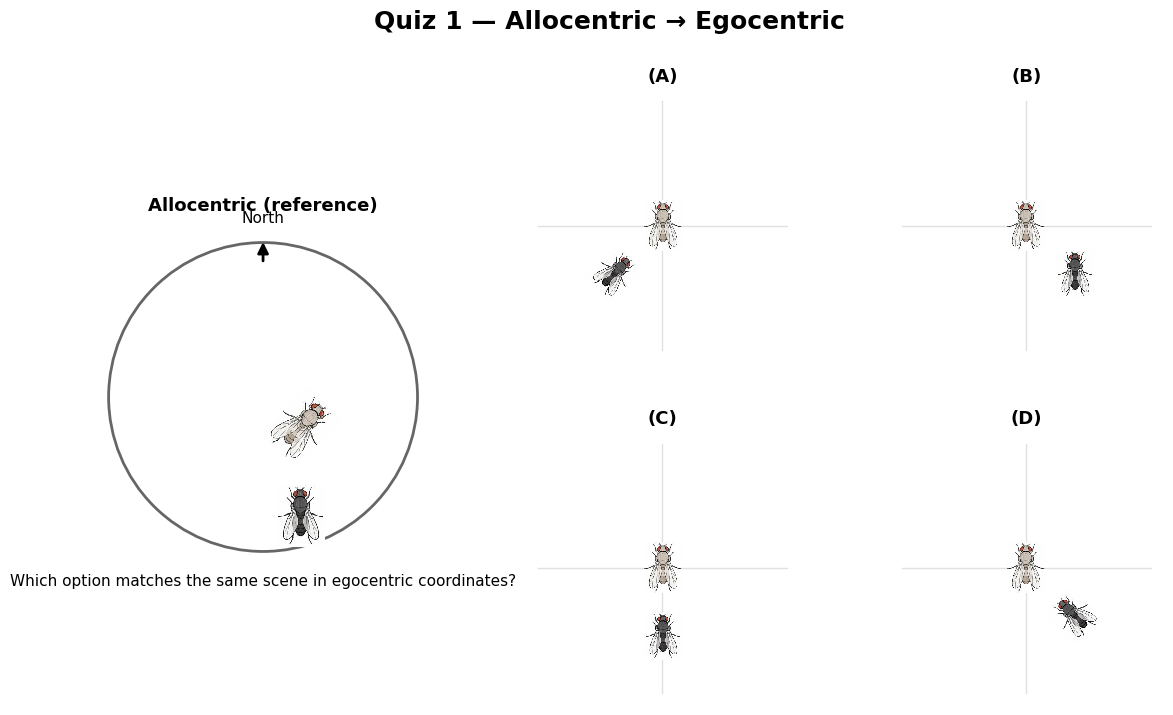

Quiz 1 — Allocentric → Egocentric | Joint allocentric offset: (+0.23, -0.19) | Correct option: (D)


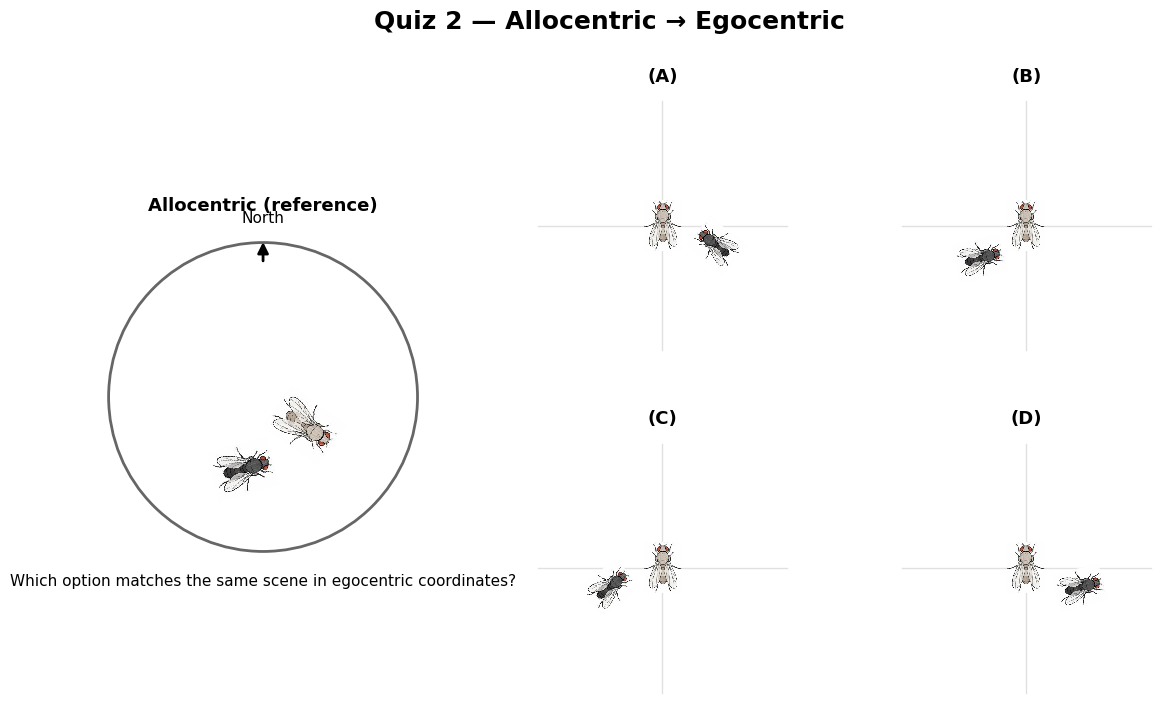

Quiz 2 — Allocentric → Egocentric | Joint allocentric offset: (+0.25, -0.18) | Correct option: (A)


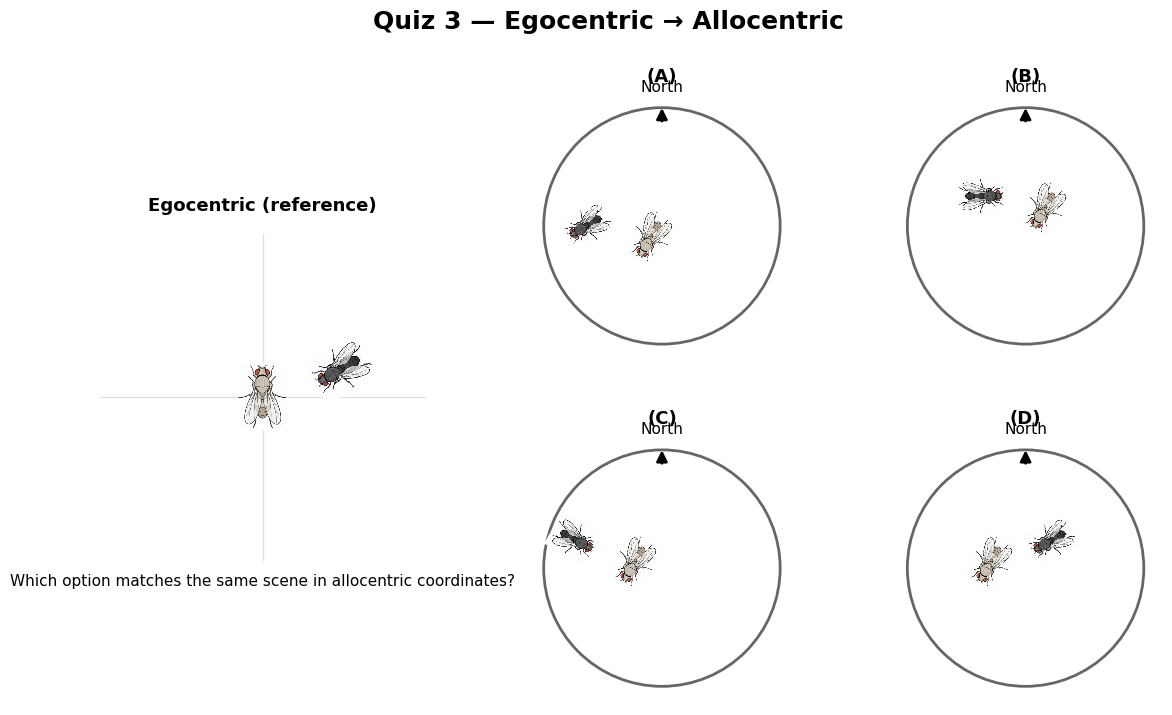

Quiz 3 — Egocentric → Allocentric | Joint allocentric offset: (-0.09, +0.15) | Correct option: (B)


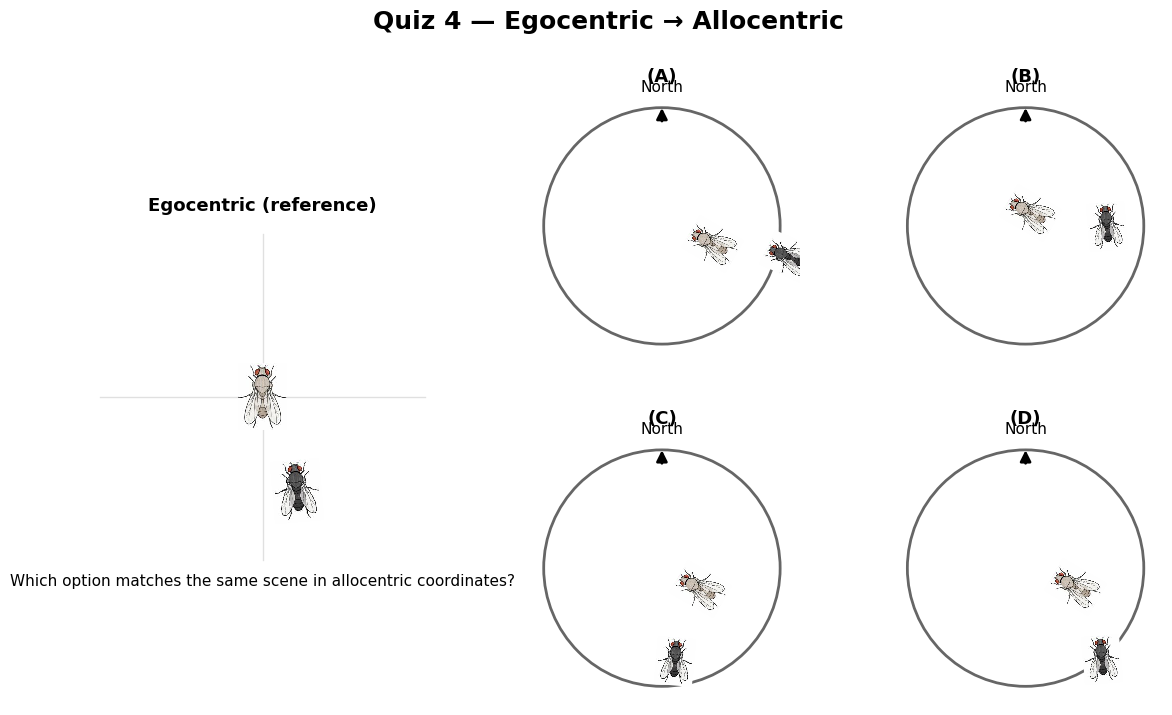

Quiz 4 — Egocentric → Allocentric | Joint allocentric offset: (+0.23, -0.04) | Correct option: (A)


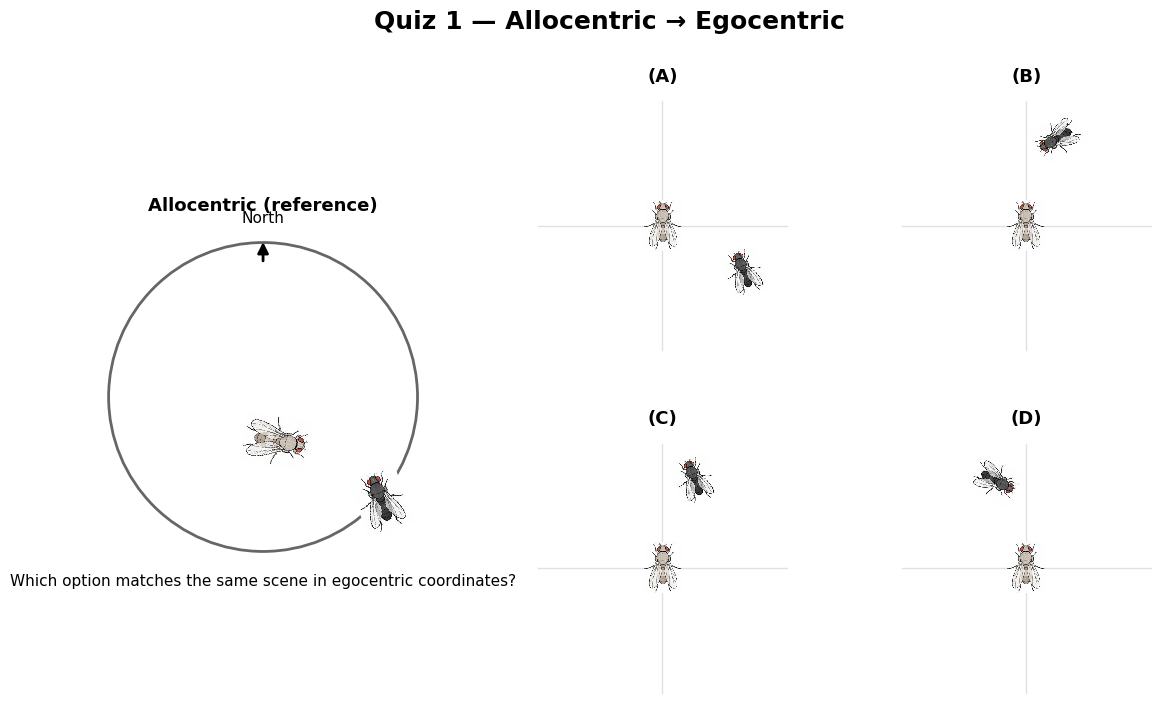

Quiz 1 — Allocentric → Egocentric | Joint allocentric offset: (+0.08, -0.27) | Correct option: (B)


In [33]:
QUIZ_SEED = 20260225

base_quiz_configs = [
    {
        'mode': 'alloc_to_ego',
        'title': 'Quiz 1 — Allocentric → Egocentric',
        'anchor_pos_alloc': [0.0, 0.0],
        'anchor_heading_north_cw': 45,
        'target_distance': 0.55,
        'target_rel_bearing_ego': 135,
        'target_heading_offset_from_anchor_deg': 0
    },
    {
        'mode': 'alloc_to_ego',
        'title': 'Quiz 2 — Allocentric → Egocentric',
        'anchor_pos_alloc': [0.0, 0.0],
        'anchor_heading_north_cw': 125,
        'target_distance': 0.46,
        'target_rel_bearing_ego': 110,
        'target_heading_offset_from_anchor_deg': 20
    },
    {
        'mode': 'ego_to_alloc',
        'title': 'Quiz 3 — Egocentric → Allocentric',
        'anchor_pos_alloc': [0.0, 0.0],
        'anchor_heading_north_cw': 210,
        'target_distance': 0.52,
        'target_rel_bearing_ego': 70,
        'target_heading_offset_from_anchor_deg': -10
    },
    {
        'mode': 'ego_to_alloc',
        'title': 'Quiz 4 — Egocentric → Allocentric',
        'anchor_pos_alloc': [0.0, 0.0],
        'anchor_heading_north_cw': 300,
        'target_distance': 0.62,
        'target_rel_bearing_ego': 160,
        'target_heading_offset_from_anchor_deg': 15
    },
        {
        'mode': 'alloc_to_ego',
        'title': 'Quiz 1 — Allocentric → Egocentric',
        'anchor_pos_alloc': [0.0, 0.0],
        'anchor_heading_north_cw': 100,
        'target_distance': 0.75,
        'target_rel_bearing_ego': 20,
        'target_heading_offset_from_anchor_deg': 40
    }
]

def sample_joint_offset(rng, min_radius=0.15, max_radius=0.35):
    radius = rng.uniform(min_radius, max_radius)
    angle = rng.uniform(0, 2 * np.pi)
    return np.array([radius * np.cos(angle), radius * np.sin(angle)])

rng = np.random.default_rng(QUIZ_SEED)
quiz_configs = []
for cfg in base_quiz_configs:
    shifted_cfg = cfg.copy()
    shift = sample_joint_offset(rng)
    shifted_cfg['anchor_pos_alloc'] = [float(shift[0]), float(shift[1])]
    quiz_configs.append(shifted_cfg)

for idx, cfg in enumerate(quiz_configs, start=1):
    fig, scene, options, correct_option = render_quiz(cfg, randomize=True, seed=QUIZ_SEED + idx)
    plt.show()
    print(f"{cfg['title']} | Joint allocentric offset: ({cfg['anchor_pos_alloc'][0]:+.2f}, {cfg['anchor_pos_alloc'][1]:+.2f}) | Correct option: ({correct_option})")

## Batch export (optional)

Exports quiz images and prints each answer key in notebook text output.

Quiz 1 — Allocentric → Egocentric | Correct option: (D) | generated_quizzes\quiz_01.png
Quiz 2 — Allocentric → Egocentric | Correct option: (A) | generated_quizzes\quiz_02.png
Quiz 3 — Egocentric → Allocentric | Correct option: (B) | generated_quizzes\quiz_03.png
Quiz 4 — Egocentric → Allocentric | Correct option: (A) | generated_quizzes\quiz_04.png
Quiz 1 — Allocentric → Egocentric | Correct option: (B) | generated_quizzes\quiz_05.png


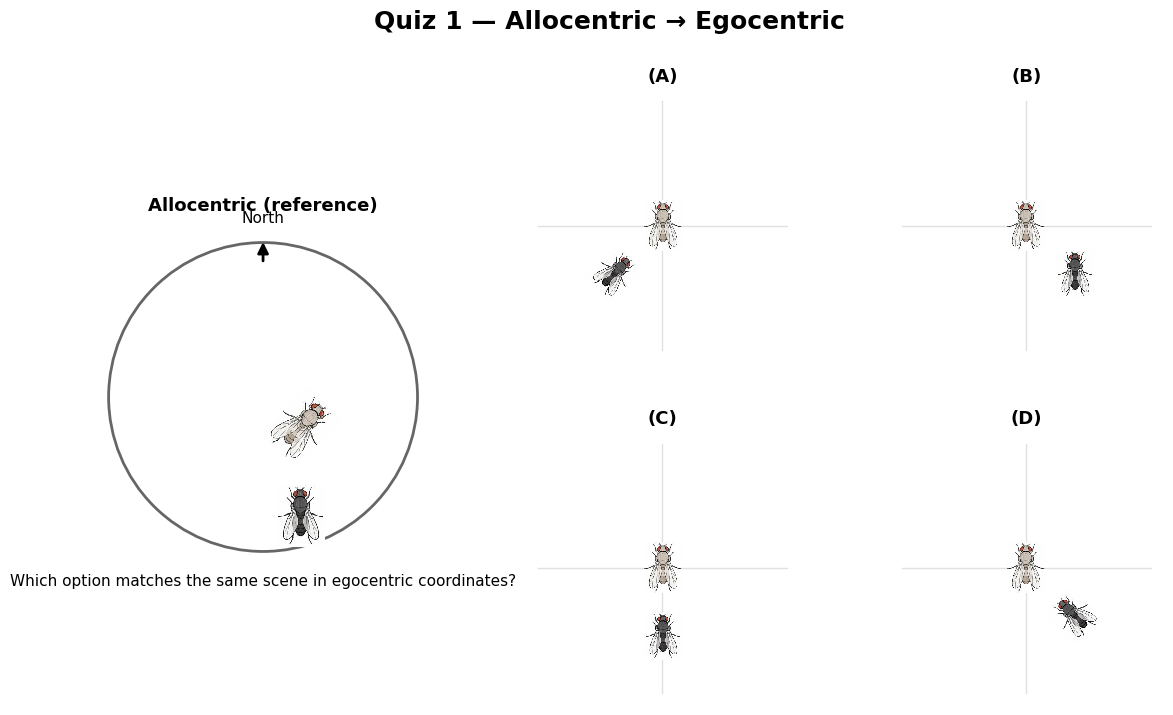

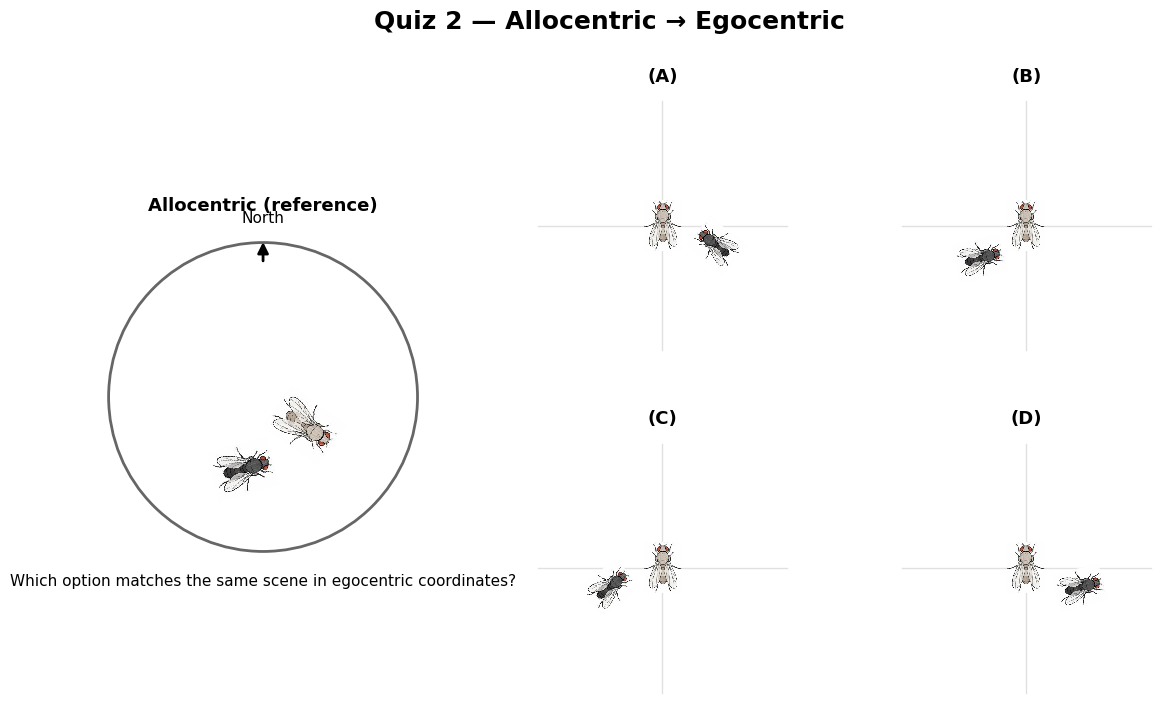

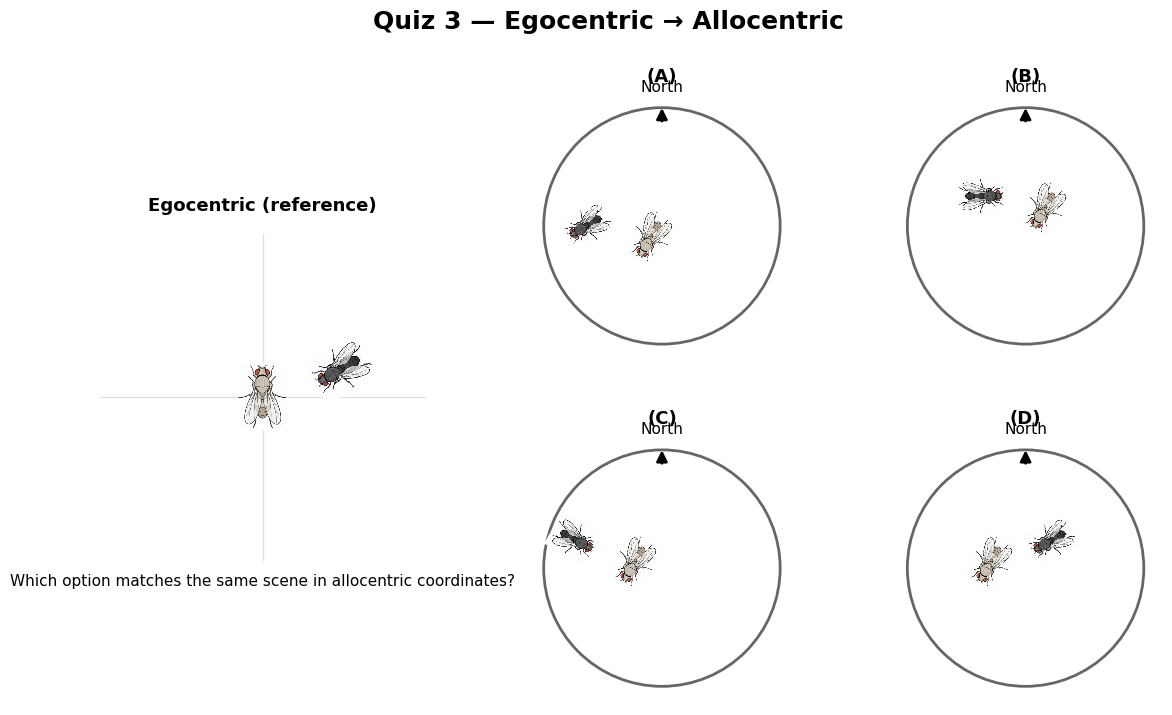

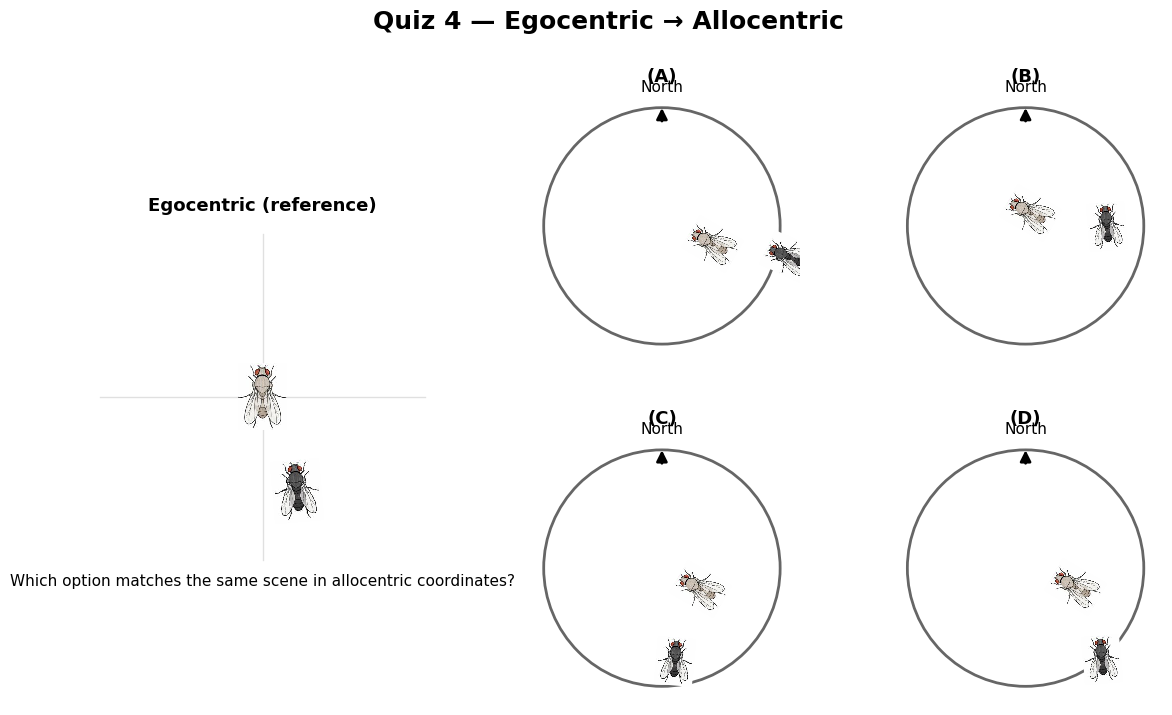

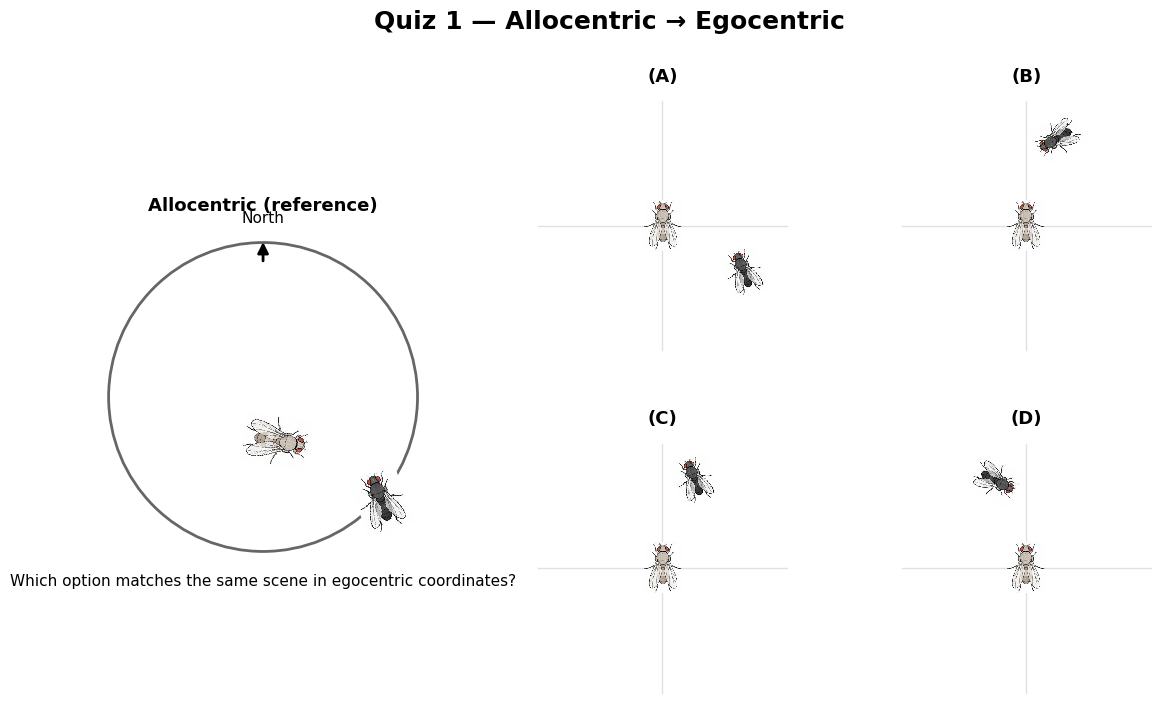

In [34]:
batch_results = generate_quiz_batch(
    quiz_configs,
    save_dir='generated_quizzes',
    dpi=220,
    close_after_save=False,
    randomize=True,
    seed=QUIZ_SEED
)

for item in batch_results:
    print(f"{item['title']} | Correct option: ({item['correct_option']}) | {item['path']}")